In [2]:
#!pip install pymfe

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from time import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import cross_validate, StratifiedKFold, LeaveOneOut
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, f1_score

from pymfe.mfe import MFE

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Passo 1: Obter conjunto de datasets de treinamento

In [4]:
#Carregando os datasets
from sklearn.datasets import fetch_openml

names = ['diabetes', 'blood-transfusion-service-center',
         'monks-problems-2', 'tic-tac-toe', 'titanic', 'pc1',
         'kr-vs-kp', 'phoneme', 'wdbc', 'semeion', 'isolet',
         'cnae-9', 'ilpd-numeric', 'students_scores',
         'usps', 'ibm-employee-performance','mushroom',
         'segment',  'autoUniv-au1-1000', 'pizzacutter3', 
         'qsar', 'solar-flare']

#errors: 'sick-numeric', 'telco-custumer-churn', 'credit-g', 'anneal'
#Too big: 'kits'

datasets = {} 
for name in names:
    print('Fetching dataset: {}'.format(name))
    datasets[name] = fetch_openml(name=name, as_frame=True)

print(f'Finished fetching {len(datasets)} datasets.')


Fetching dataset: diabetes
Fetching dataset: blood-transfusion-service-center
Fetching dataset: monks-problems-2
Fetching dataset: tic-tac-toe
Fetching dataset: titanic
Fetching dataset: pc1
Fetching dataset: kr-vs-kp
Fetching dataset: phoneme
Fetching dataset: wdbc
Fetching dataset: semeion
Fetching dataset: isolet


/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name diabetes exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=37
- version 5, status: active
  url: https://www.openml.org/search?type=data&id=42608

  warn(warning_msg)
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name blood-transfusion-service-center exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1464
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=46913

  warn(warning_msg)
/opt/homebre

Fetching dataset: cnae-9
Fetching dataset: ilpd-numeric
Fetching dataset: students_scores
Fetching dataset: usps


/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name cnae-9 exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1468
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=41967

  warn(warning_msg)
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name ilpd-numeric exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=41943
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=41945

  warn(warning_msg)
/opt/homebrew/Caskroom/minicond

Fetching dataset: ibm-employee-performance
Fetching dataset: mushroom
Fetching dataset: segment
Fetching dataset: autoUniv-au1-1000
Fetching dataset: pizzacutter3
Fetching dataset: qsar
Fetching dataset: solar-flare
Finished fetching 22 datasets.


/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name ibm-employee-performance exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=43895
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=43897

  warn(warning_msg)
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name mushroom exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=24
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=43922

  warn(warning_msg)
/opt/homebrew/Caskr

## Passo 2: Avaliar performance dos classificadores nos datasets

In [5]:
# Define classifiers
from sklearn.impute import SimpleImputer


classifiers = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'Perceptron': Perceptron(random_state=42, max_iter=1000),
    'MLP': MLPClassifier(random_state=42, max_iter=1000)
}

# Store results
results = []

# Iterate through datasets
for dataset_name in names:
    print(f'Processing dataset: {dataset_name}')
    
    # Get data and target
    X = datasets[dataset_name]['data']
    y = datasets[dataset_name]['target']
    
    # Handle missing values
    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        print(f'Warning: Imputation failed for {dataset_name} with error: {e}')
        print('Falling back to simple imputation strategy.')
        # Use most frequent strategy for string/categorical data
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        # Fit and transform the data
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


    # Handle categorical features
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    
    # Encode target if necessary
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)
    
    # Evaluate each classifier
    for clf_name, clf in classifiers.items():
        print(f'  Evaluating {clf_name}...', end=' ')
        
        # 5-fold cross validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_results = cross_validate(clf, X, y, cv=cv, scoring='accuracy', 
                                    return_train_score=False)
        
        # Extract fold accuracies
        fold_accs = cv_results['test_score']
        
        # Create result row
        result_row = {
            'Dataset': dataset_name,
            'Classifier': clf_name,
            'acc_fold1': fold_accs[0],
            'acc_fold2': fold_accs[1],
            'acc_fold3': fold_accs[2],
            'acc_fold4': fold_accs[3],
            'acc_fold5': fold_accs[4],
            'acc_mean': fold_accs.mean(),
            'acc_stddev': fold_accs.std(),
            'train_time': cv_results['fit_time'].sum(),
            'test_time': cv_results['score_time'].sum()
        }
        
        results.append(result_row)
        print('Done')

# Create results DataFrame
performances_df = pd.DataFrame(results)

Processing dataset: diabetes
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: blood-transfusion-service-center
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: monks-problems-2
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Conv

Done
Processing dataset: tic-tac-toe
Falling back to simple imputation strategy.
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Conv

Done
Processing dataset: titanic
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: pc1
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... 

...

Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: autoUniv-au1-1000
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Conv

Done
Processing dataset: pizzacutter3
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to s

Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: qsar
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: solar-flare
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done


In [21]:
# Saving results to CSV
performances_df.to_csv('classifier_performances.csv', index=False)

In [23]:
# Loading results from CSV
performances_df = pd.read_csv('classifier_performances.csv')


In [24]:
performances_df

,Dataset,Classifier,acc_fold1,acc_fold2,acc_fold3,acc_fold4,acc_fold5,acc_mean,acc_stddev,train_time,test_time
0,diabetes,DecisionTree,0.727273,0.733766,0.707792,0.712418,0.620915,0.700433,0.040871,0.020544,0.005750
1,diabetes,SVM,0.759740,0.805195,0.753247,0.732026,0.751634,0.760368,0.024249,0.047810,0.024054
2,diabetes,KNN,0.714286,0.753247,0.662338,0.692810,0.666667,0.697869,0.033460,0.006603,0.010406
3,diabetes,LogisticRegression,0.779221,0.779221,0.785714,0.764706,0.745098,0.770792,0.014574,0.089839,0.006997
4,diabetes,Perceptron,0.616883,0.629870,0.623377,0.352941,0.653595,0.575333,0.111886,0.012231,0.007863
...,...,...,...,...,...,...,...,...,...,...,...
127,solar-flare,SVM,0.746032,0.761905,0.730159,0.730159,0.714286,0.736508,0.016187,0.022030,0.009396
128,solar-flare,KNN,0.587302,0.714286,0.587302,0.730159,0.714286,0.666667,0.065060,0.005892,0.009568
129,solar-flare,LogisticRegression,0.714286,0.761905,0.730159,0.761905,0.682540,0.730159,0.030117,0.259444,0.008174
130,solar-flare,Perceptron,0.460317,0.666667,0.619048,0.539683,0.634921,0.584127,0.074721,0.023855,0.007233


## Passo 3: Extrair meta-features dos datasets

In [7]:
# Extract meta-features
meta_features = []

for dataset_name in names:  
    print(f'Extracting meta-features from {dataset_name}...', end=' ')
    
    # Get data and target
    X = datasets[dataset_name]['data']
    y = datasets[dataset_name]['target']
    
    # Handle categorical features
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    
    # Handle missing values
    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    
    # Encode target if necessary
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        # Convert to numpy array if it's a pandas Series
        y = np.array(y)
    
    # Extract meta-features
    try:
        mfe = MFE(groups=["general", "statistical", "info-theory", 
                          "clustering", #"concept", "model_based", "landmarking", "complexity",
                          ], summary='mean')
        mfe.fit(X.values, y)
        ft = mfe.extract()
        
        # Create result row with dataset name and meta-features
        result_row = {'dataset': dataset_name}
        
        meta_features.append(pd.DataFrame(dict(zip(ft[0], ft[1])), index=[dataset_name]))
        print('Done')
    except Exception as e:
        print(f'Error: {e}')

# Create meta-features DataFrame
meta_features_df = pd.concat(meta_features, ignore_index=False)

Extracting meta-features from diabetes... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")


Done
Extracting meta-features from blood-transfusion-service-center... Done
Extracting meta-features from monks-problems-2... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/statistical.py:1266: RuntimeWarning: invalid value encountered in log
  np.log(np.linalg.det(S_i)) for S_i in sample_cov_matrices
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/statistical.py:1271: RuntimeWarning: invalid value encountered in log
  * np.log(np.linalg.det(pooled_cov_mat))


Done
Extracting meta-features from tic-tac-toe... 

...

Done
Extracting meta-features from qsar... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:732: RuntimeWarning: Can't summarize feature 'g_mean' with summary 'mean'. Will set it as 'np.nan'.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:611: RuntimeWarning: The harmonic mean is only defined if all elements are non-negative; otherwise, the result is NaN.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:732: RuntimeWarning: Can't summarize feature 'h_mean' with summary 'mean'. Will set it as 'np.nan'.
  warnings.warn(
/opt

Done
Extracting meta-features from solar-flare... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/statistical.py:1266: RuntimeWarning: divide by zero encountered in log
  np.log(np.linalg.det(S_i)) for S_i in sample_cov_matrices


Done


In [25]:
# Saving meta-features to CSV
meta_features_df.to_csv('dataset_meta_features.csv', index=True)

In [27]:
# Loading meta-features from CSV
meta_features_df = pd.read_csv('dataset_meta_features.csv', index_col=0)

In [28]:
meta_features_df

,attr_conc.mean,attr_ent.mean,attr_to_inst,can_cor.mean,cat_to_num,ch,class_conc.mean,class_ent,cor.mean,cov.mean,...,sd.mean,sd_ratio,sil,skewness.mean,sparsity.mean,t_mean.mean,var.mean,vdb,vdu,w_lambda
diabetes,0.028840,2.958106,0.010417,0.550684,0.0,24.299108,0.012490,0.933134,0.171657,1.093502e+02,...,25.733743,1.032594,0.104260,0.527181,0.015923,40.209208,1.893059e+03,4.427474,3.677824e-08,6.967469e-01
blood-transfusion-service-center,0.222062,2.882541,0.005348,0.359244,0.0,37.439438,0.010159,0.791645,0.465998,5.568267e+03,...,374.534549,1.082778,0.178546,2.254043,0.025118,267.449444,5.329470e+05,2.841441,0.000000e+00,8.709436e-01
monks-problems-2,0.000490,1.458931,0.009983,0.139975,0.0,1.992991,0.002467,0.927437,0.013879,8.194676e-03,...,0.759888,NaN,-0.001832,-0.003244,0.373958,1.915974,6.221104e-01,16.096022,2.562547e-06,9.804071e-01
tic-tac-toe,0.014676,1.538037,0.009395,0.966025,NaN,19.371543,0.015851,0.930954,0.125923,2.937108e-02,...,0.481048,NaN,0.023668,0.524541,0.332637,0.294042,2.317603e-01,6.684681,2.083475e-06,6.679638e-02
titanic,0.054809,0.958873,0.001363,0.470040,0.0,236.113508,0.080603,0.907651,0.185447,1.856629e-01,...,1.000460,NaN,0.234431,0.683594,0.416402,0.151765,1.000920e+00,2.585854,0.000000e+00,7.790622e-01
pc1,0.216429,2.937619,0.018936,0.386223,0.0,15.547851,0.006607,0.363800,0.632733,9.113908e+06,...,8678.609589,NaN,0.620808,7.986854,0.012637,266.343759,1.391022e+09,2.173658,0.000000e+00,8.508315e-01
kr-vs-kp,0.014611,0.590148,0.011264,0.799823,NaN,97.003172,0.023128,0.998576,0.085644,1.123369e-02,...,0.332009,NaN,0.031625,4.108820,0.495212,0.224809,1.303675e-01,5.676987,8.009382e-08,3.602836e-01
phoneme,0.057846,4.025713,0.000925,0.497794,0.0,408.510486,0.010767,0.873182,0.126089,1.260889e-01,...,1.000000,1.234492,0.087266,0.779033,0.000010,-0.151914,1.000000e+00,3.102294,5.578544e-10,7.522012e-01
wdbc,0.052249,2.999956,0.052724,0.879957,0.0,633.631104,0.051585,0.952635,0.394897,6.764651e+02,...,34.904719,NaN,0.513697,1.731241,0.000209,53.294606,1.506322e+04,0.720645,3.317102e-08,2.256753e-01
semeion,0.031348,0.875007,0.160703,0.788536,0.0,41.251899,0.188329,3.321819,0.096662,2.013985e-02,...,0.455351,NaN,0.049640,0.807858,0.499686,0.222550,2.092574e-01,3.661805,1.756471e-05,3.074668e-05


# Passo 4: Combinar as meta-features e as performances

In [9]:
performances_df

,Dataset,Classifier,acc_fold1,acc_fold2,acc_fold3,acc_fold4,acc_fold5,acc_mean,acc_stddev,train_time,test_time
0,diabetes,DecisionTree,0.727273,0.733766,0.707792,0.712418,0.620915,0.700433,0.040871,0.020544,0.005750
1,diabetes,SVM,0.759740,0.805195,0.753247,0.732026,0.751634,0.760368,0.024249,0.047810,0.024054
2,diabetes,KNN,0.714286,0.753247,0.662338,0.692810,0.666667,0.697869,0.033460,0.006603,0.010406
3,diabetes,LogisticRegression,0.779221,0.779221,0.785714,0.764706,0.745098,0.770792,0.014574,0.089839,0.006997
4,diabetes,Perceptron,0.616883,0.629870,0.623377,0.352941,0.653595,0.575333,0.111886,0.012231,0.007863
...,...,...,...,...,...,...,...,...,...,...,...
127,solar-flare,SVM,0.746032,0.761905,0.730159,0.730159,0.714286,0.736508,0.016187,0.022030,0.009396
128,solar-flare,KNN,0.587302,0.714286,0.587302,0.730159,0.714286,0.666667,0.065060,0.005892,0.009568
129,solar-flare,LogisticRegression,0.714286,0.761905,0.730159,0.761905,0.682540,0.730159,0.030117,0.259444,0.008174
130,solar-flare,Perceptron,0.460317,0.666667,0.619048,0.539683,0.634921,0.584127,0.074721,0.023855,0.007233


In [10]:
# Reshape performances_df to have one row per dataset and the performance (acc_mean) of each classifier as a separate column
performances_df2 = performances_df.pivot(index='Dataset', columns='Classifier', values='acc_mean')
performances_df2.columns.name = None
performances_df2 = performances_df2.reset_index()
performances_df2

,Dataset,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM
0,autoUniv-au1-1000,0.651000,0.734000,0.735000,0.703000,0.697000,0.758000
1,blood-transfusion-service-center,0.709852,0.762058,0.772707,0.673942,0.636385,0.759365
2,cnae-9,0.864815,0.854630,0.940741,0.955556,0.927778,0.919444
3,diabetes,0.700433,0.697869,0.770792,0.658925,0.575333,0.760368
4,ibm-employee-performance,1.000000,0.829252,0.961224,0.904082,0.814966,0.846259
5,ilpd-numeric,0.638093,0.674138,0.718700,0.704907,0.663719,0.713557
6,isolet,0.812749,0.890984,0.960241,0.961396,0.947671,0.961139
7,kr-vs-kp,0.995620,0.957761,0.960576,0.993742,0.940232,0.973092
8,monks-problems-2,0.991667,0.602259,0.640606,0.750441,0.603912,0.677204
9,mushroom,1.000000,0.998892,0.955810,1.000000,0.887494,0.990399


In [11]:
# Merge performances_df2 with meta_features_df based on dataset name
meta_dataset = performances_df2.merge(
    right=meta_features_df, 
    left_on='Dataset', 
    right_index=True, 
    how='left'
)

# Reorder columns: 'Dataset' first, then meta-features, then classifiers
meta_cols = meta_features_df.columns.tolist()
classifier_cols = performances_df2.columns.drop('Dataset').tolist()
meta_dataset = meta_dataset[['Dataset'] + meta_cols + classifier_cols]

In [12]:
meta_dataset

,Dataset,attr_conc.mean,attr_ent.mean,attr_to_inst,can_cor.mean,cat_to_num,ch,class_conc.mean,class_ent,cor.mean,...,var.mean,vdb,vdu,w_lambda,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM
0,autoUniv-au1-1000,0.004399,0.959212,0.020000,0.309874,0.0,4.879801,0.005145,0.825234,0.039626,...,2.366491e-01,12.510967,1.195378e-06,9.039781e-01,0.651000,0.734000,0.735000,0.703000,0.697000,0.758000
1,blood-transfusion-service-center,0.222062,2.882541,0.005348,0.359244,0.0,37.439438,0.010159,0.791645,0.465998,...,5.329470e+05,2.841441,0.000000e+00,8.709436e-01,0.709852,0.762058,0.772707,0.673942,0.636385,0.759365
2,cnae-9,0.015155,0.050160,0.792593,0.975141,0.0,28.121009,0.034934,3.169925,0.009671,...,8.251032e-03,3.832115,8.018754e-06,8.588353e-12,0.864815,0.854630,0.940741,0.955556,0.927778,0.919444
3,diabetes,0.028840,2.958106,0.010417,0.550684,0.0,24.299108,0.012490,0.933134,0.171657,...,1.893059e+03,4.427474,3.677824e-08,6.967469e-01,0.700433,0.697869,0.770792,0.658925,0.575333,0.760368
4,ibm-employee-performance,0.049252,2.137001,0.022449,0.776640,0.0,0.230819,0.048857,0.619125,NaN,...,2.222840e+06,53.157342,1.962878e-08,3.968296e-01,1.000000,0.829252,0.961224,0.904082,0.814966,0.846259
5,ilpd-numeric,0.046057,2.677291,0.017153,0.346650,0.0,16.420895,0.012178,0.864090,0.179914,...,1.761536e+04,2.361913,7.079625e-09,8.798338e-01,0.638093,0.674138,0.718700,0.704907,0.663719,0.713557
6,isolet,0.018233,3.902519,0.079133,0.776810,0.0,273.604499,0.072781,4.700438,0.173298,...,1.862294e-01,3.695307,2.533339e-06,1.357282e-14,0.812749,0.890984,0.960241,0.961396,0.947671,0.961139
7,kr-vs-kp,0.014611,0.590148,0.011264,0.799823,NaN,97.003172,0.023128,0.998576,0.085644,...,1.303675e-01,5.676987,8.009382e-08,3.602836e-01,0.995620,0.957761,0.960576,0.993742,0.940232,0.973092
8,monks-problems-2,0.000490,1.458931,0.009983,0.139975,0.0,1.992991,0.002467,0.927437,0.013879,...,6.221104e-01,16.096022,2.562547e-06,9.804071e-01,0.991667,0.602259,0.640606,0.750441,0.603912,0.677204
9,mushroom,0.105408,1.409255,0.002708,1.000000,NaN,1075.059896,0.127349,0.999068,0.095319,...,9.336038e-02,2.727542,1.858092e-08,5.773160e-15,1.000000,0.998892,0.955810,1.000000,0.887494,0.990399


In [13]:
# Get the classifier columns (last 6 columns)
classifier_cols = meta_dataset.columns[-6:].tolist()

# Find the classifier with the best (maximum) accuracy for each dataset
meta_dataset['Best'] = meta_dataset[classifier_cols].idxmax(axis=1)

In [14]:
meta_dataset

,Dataset,attr_conc.mean,attr_ent.mean,attr_to_inst,can_cor.mean,cat_to_num,ch,class_conc.mean,class_ent,cor.mean,...,vdb,vdu,w_lambda,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Best
0,autoUniv-au1-1000,0.004399,0.959212,0.020000,0.309874,0.0,4.879801,0.005145,0.825234,0.039626,...,12.510967,1.195378e-06,9.039781e-01,0.651000,0.734000,0.735000,0.703000,0.697000,0.758000,SVM
1,blood-transfusion-service-center,0.222062,2.882541,0.005348,0.359244,0.0,37.439438,0.010159,0.791645,0.465998,...,2.841441,0.000000e+00,8.709436e-01,0.709852,0.762058,0.772707,0.673942,0.636385,0.759365,LogisticRegression
2,cnae-9,0.015155,0.050160,0.792593,0.975141,0.0,28.121009,0.034934,3.169925,0.009671,...,3.832115,8.018754e-06,8.588353e-12,0.864815,0.854630,0.940741,0.955556,0.927778,0.919444,MLP
3,diabetes,0.028840,2.958106,0.010417,0.550684,0.0,24.299108,0.012490,0.933134,0.171657,...,4.427474,3.677824e-08,6.967469e-01,0.700433,0.697869,0.770792,0.658925,0.575333,0.760368,LogisticRegression
4,ibm-employee-performance,0.049252,2.137001,0.022449,0.776640,0.0,0.230819,0.048857,0.619125,NaN,...,53.157342,1.962878e-08,3.968296e-01,1.000000,0.829252,0.961224,0.904082,0.814966,0.846259,DecisionTree
5,ilpd-numeric,0.046057,2.677291,0.017153,0.346650,0.0,16.420895,0.012178,0.864090,0.179914,...,2.361913,7.079625e-09,8.798338e-01,0.638093,0.674138,0.718700,0.704907,0.663719,0.713557,LogisticRegression
6,isolet,0.018233,3.902519,0.079133,0.776810,0.0,273.604499,0.072781,4.700438,0.173298,...,3.695307,2.533339e-06,1.357282e-14,0.812749,0.890984,0.960241,0.961396,0.947671,0.961139,MLP
7,kr-vs-kp,0.014611,0.590148,0.011264,0.799823,NaN,97.003172,0.023128,0.998576,0.085644,...,5.676987,8.009382e-08,3.602836e-01,0.995620,0.957761,0.960576,0.993742,0.940232,0.973092,DecisionTree
8,monks-problems-2,0.000490,1.458931,0.009983,0.139975,0.0,1.992991,0.002467,0.927437,0.013879,...,16.096022,2.562547e-06,9.804071e-01,0.991667,0.602259,0.640606,0.750441,0.603912,0.677204,DecisionTree
9,mushroom,0.105408,1.409255,0.002708,1.000000,NaN,1075.059896,0.127349,0.999068,0.095319,...,2.727542,1.858092e-08,5.773160e-15,1.000000,0.998892,0.955810,1.000000,0.887494,0.990399,DecisionTree


In [15]:
pd.DataFrame(meta_dataset['Best'].value_counts())

,count
Best,
MLP,6
DecisionTree,6
LogisticRegression,5
SVM,4
KNN,1


# Passo 5: Treinar (e avaliar) o meta-modelo

In [16]:
# Create a dictionary to store the reuslts:
summary_of_predictions = {'Dataset':[], 'Best clf (true)':[], 'Perf of best clf (true)':[],
                           'Best clf (pred)':[], 'Perf of best clf (pred)':[]}

loo = LeaveOneOut()
feat_import_perf_fold = []
y_true = meta_dataset['Best'].values
y_pred = []

for train_index, test_index in loo.split(meta_dataset):
    # Split the data into training and test sets
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols) # Drop everything except meta-features
    y = meta_dataset['Best']
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train a simple classifier (e.g., Decision Tree) on the training set
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    
    # Predict the best classifier for the test dataset
    y_pred.append(clf.predict(X_test)[0])
    
    # Store results in the summary dictionary
    summary_of_predictions['Dataset'].append(meta_dataset['Dataset'].iloc[test_index].values[0])
    summary_of_predictions['Best clf (true)'].append(y_test.values[0])
    summary_of_predictions['Perf of best clf (true)'].append(meta_dataset.loc[test_index, y_test.values[0]].values[0])
    summary_of_predictions['Best clf (pred)'].append(y_pred[-1])
    summary_of_predictions['Perf of best clf (pred)'].append(meta_dataset.loc[test_index, y_pred[-1]].values[0])


# Create a DataFrame from the summary of predictions
summary_df = pd.DataFrame(summary_of_predictions)

# Calculate meta-model accuracy and F1-score
meta_model_accuracy = accuracy_score(y_true, y_pred)
meta_model_f1 = f1_score(y_true, y_pred, average='weighted')
print(f'Meta-model Accuracy: {meta_model_accuracy:.2f}')
print(f'Meta-model F1-score: {meta_model_f1:.2f}')


Meta-model Accuracy: 0.23
Meta-model F1-score: 0.22


In [17]:
summary_df

,Dataset,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,autoUniv-au1-1000,SVM,0.758000,DecisionTree,0.651000
1,blood-transfusion-service-center,LogisticRegression,0.772707,LogisticRegression,0.772707
2,cnae-9,MLP,0.955556,DecisionTree,0.864815
3,diabetes,LogisticRegression,0.770792,DecisionTree,0.700433
4,ibm-employee-performance,DecisionTree,1.000000,LogisticRegression,0.961224
5,ilpd-numeric,LogisticRegression,0.718700,LogisticRegression,0.718700
6,isolet,MLP,0.961396,SVM,0.961139
7,kr-vs-kp,DecisionTree,0.995620,MLP,0.993742
8,monks-problems-2,DecisionTree,0.991667,MLP,0.750441
9,mushroom,DecisionTree,1.000000,DecisionTree,1.000000


In [18]:
# Base-level performance:
summary_df.describe()


,Perf of best clf (true),Perf of best clf (pred)
count,22.000000,22.000000
mean,0.893961,0.854170
std,0.094263,0.107603
min,0.718700,0.651000
25%,0.812109,0.756007
50%,0.925093,0.866407
75%,0.963726,0.955594
max,1.000000,1.000000


In [19]:
final_summary = pd.concat([performances_df2, summary_df], axis=1)
# Drop second 'Dataset' column
idx_to_drop = list(final_summary.columns).index('Dataset', 1)  # Find the index of the second 'Dataset' column
final_summary = final_summary.drop(columns=final_summary.columns[idx_to_drop], axis=1)
final_summary

,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,0.651000,0.734000,0.735000,0.703000,0.697000,0.758000,SVM,0.758000,DecisionTree,0.651000
1,0.709852,0.762058,0.772707,0.673942,0.636385,0.759365,LogisticRegression,0.772707,LogisticRegression,0.772707
2,0.864815,0.854630,0.940741,0.955556,0.927778,0.919444,MLP,0.955556,DecisionTree,0.864815
3,0.700433,0.697869,0.770792,0.658925,0.575333,0.760368,LogisticRegression,0.770792,DecisionTree,0.700433
4,1.000000,0.829252,0.961224,0.904082,0.814966,0.846259,DecisionTree,1.000000,LogisticRegression,0.961224
5,0.638093,0.674138,0.718700,0.704907,0.663719,0.713557,LogisticRegression,0.718700,LogisticRegression,0.718700
6,0.812749,0.890984,0.960241,0.961396,0.947671,0.961139,MLP,0.961396,SVM,0.961139
7,0.995620,0.957761,0.960576,0.993742,0.940232,0.973092,DecisionTree,0.995620,MLP,0.993742
8,0.991667,0.602259,0.640606,0.750441,0.603912,0.677204,DecisionTree,0.991667,MLP,0.750441
9,1.000000,0.998892,0.955810,1.000000,0.887494,0.990399,DecisionTree,1.000000,DecisionTree,1.000000


<Axes: >

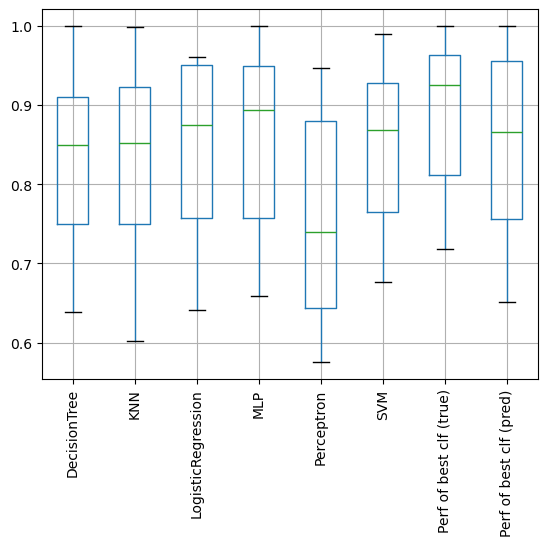

In [20]:
final_summary.boxplot(rot=90)